# 식수 인원 예측 고도화 실험: V5-Drop

이 노트북은 2016년 6월의 데이터 정제 전략 중 **'일부 데이터 제거(Drop)'**를 적용한 실험 버전입니다.
- **데이터 전략**: 6월 13일~30일의 결측 문제를 해결하기 위해, 6월 1일~12일 데이터를 제거한 `train_drop.csv`를 사용합니다.
- **모델 아키텍처**: V5의 고도화된 앙상블(XGB, LGBM, Cat) 및 OOF 동적 가중치 방식을 적용합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

import korean_font
korean_font.set_korean_font()

한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)


## 1. 데이터 로드 및 노이즈 제거된 병합

In [2]:
train = pd.read_csv('data/train_drop.csv')
test = pd.read_csv('data/test.csv')
weather = pd.read_csv('data/weather.csv')
submission = pd.read_csv('data/sample_submission.csv')

train['일자'] = pd.to_datetime(train['일자'])
test['일자'] = pd.to_datetime(test['일자'])
weather['일시'] = pd.to_datetime(weather['일시'])

weather_subset = weather[['일시', '기온', '강수량']].copy()
weather_subset.columns = ['일시', 'temp', 'rain']

train = pd.merge(train, weather_subset, left_on='일자', right_on='일시', how='left')
test = pd.merge(test, weather_subset, left_on='일자', right_on='일시', how='left')

train['rain'] = train['rain'].fillna(0)
test['rain'] = test['rain'].fillna(0)
train['temp'] = train['temp'].fillna(train['temp'].mean())
test['temp'] = test['temp'].fillna(train['temp'].mean())

train['is_rain'] = train['rain'].apply(lambda x: 1 if x > 0 else 0)
test['is_rain'] = test['rain'].apply(lambda x: 1 if x > 0 else 0)

## 2. 피처 엔지니어링

In [3]:
def process_df(df):
    df['month'] = df['일자'].dt.month
    df['day'] = df['일자'].dt.day
    df['weekday'] = df['일자'].dt.weekday
    df['in_office'] = df['본사정원수'] - df['본사휴가자수'] - df['본사출장자수'] - df['현본사소속재택근무자수']
    return df

train = process_df(train)
test = process_df(test)

def parse_menu(menu_series):
    bob, soup, main = [], [], []
    for menu_str in menu_series:
        if pd.isna(menu_str) or menu_str.strip() == '':
            bob.append('None'); soup.append('None'); main.append('None')
            continue
        items = menu_str.split()
        clean_items = [x for x in items if '(' not in x]
        bob.append(clean_items[0] if len(clean_items) > 0 else 'None')
        soup.append(clean_items[1] if len(clean_items) > 1 else 'None')
        main.append(clean_items[2] if len(clean_items) > 2 else 'None')
    return bob, soup, main

train['lunch_bob'], train['lunch_soup'], train['lunch_main'] = parse_menu(train['중식메뉴'])
train['dinner_bob'], train['dinner_soup'], train['dinner_main'] = parse_menu(train['석식메뉴'])
test['lunch_bob'], test['lunch_soup'], test['lunch_main'] = parse_menu(test['중식메뉴'])
test['dinner_bob'], test['dinner_soup'], test['dinner_main'] = parse_menu(test['석식메뉴'])

train_dinner = train.copy()
train_dinner = train_dinner[train_dinner['석식메뉴'].str.contains('\*', na=False) == False]
train_dinner = train_dinner[train_dinner['dinner_bob'] != 'None']
train_dinner = train_dinner[train_dinner['석식계'] > 0]

def encode_features(train_df, test_df, cat_cols):
    for col in cat_cols:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        mapping = {l: i for i, l in enumerate(le.classes_)}
        test_df[col] = test_df[col].astype(str).map(lambda x: mapping.get(x, -1))
    return train_df, test_df

cat_cols = ['lunch_bob', 'lunch_soup', 'lunch_main', 'dinner_bob', 'dinner_soup', 'dinner_main']
train_l_encoded, test_l_encoded = encode_features(train.copy(), test.copy(), cat_cols)
train_d_encoded, test_d_encoded = encode_features(train_dinner.copy(), test.copy(), cat_cols)

## 3. 최적화된 앙상블 학습

In [4]:
features_l = ['weekday', 'month', 'day', 'in_office', '본사시간외근무명령서승인건수', 'temp', 'is_rain', 'lunch_bob', 'lunch_soup', 'lunch_main']
features_d = ['weekday', 'month', 'day', 'in_office', '본사시간외근무명령서승인건수', 'temp', 'is_rain', 'dinner_bob', 'dinner_soup', 'dinner_main']

def train_weighted_ensemble(X, y, test_X, target_name):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    import lightgbm as lgb
    
    models = {
        'XGB': XGBRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, colsample_bytree=0.7, random_state=42, early_stopping_rounds=50, verbosity=0),
        'LGBM': LGBMRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, colsample_bytree=0.7, random_state=42, verbosity=-1),
        'CAT': CatBoostRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=42, verbose=0, early_stopping_rounds=50)
    }
    
    oofs = {name: np.zeros(len(X)) for name in models.keys()}
    preds = {name: np.zeros(len(test_X)) for name in models.keys()}
    
    for name, model in models.items():
        for fold, (t_idx, v_idx) in enumerate(kf.split(X, y)):
            X_t, y_t = X.iloc[t_idx], y.iloc[t_idx]
            X_v, y_v = X.iloc[v_idx], y.iloc[v_idx]
            
            if name == 'XGB': model.fit(X_t, y_t, eval_set=[(X_v, y_v)], verbose=False)
            elif name == 'LGBM': model.fit(X_t, y_t, eval_set=[(X_v, y_v)], eval_metric='mae', callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
            elif name == 'CAT': model.fit(X_t, y_t, eval_set=[(X_v, y_v)], verbose=False)
            
            oofs[name][v_idx] = model.predict(X_v)
            preds[name] += model.predict(test_X) / 5
            
    maes = {name: mean_absolute_error(y, oofs[name]) for name in models.keys()}
    inv_maes = {name: 1.0/maes[name] for name in models.keys()}
    w = {name: inv_maes[name]/sum(inv_maes.values()) for name in models.keys()}
    
    final_oof = sum(oofs[name] * w[name] for name in models.keys())
    final_pred = sum(preds[name] * w[name] for name in models.keys())
    
    print(f"{target_name} OOF MAE: {mean_absolute_error(y, final_oof):.4f}, Weights: {w}")
    return final_pred, final_oof, y

res_l_pred, res_l_oof, res_l_y = train_weighted_ensemble(train_l_encoded[features_l], train_l_encoded['중식계'], test_l_encoded[features_l], "Lunch")
res_d_pred, res_d_oof, res_d_y = train_weighted_ensemble(train_d_encoded[features_d], train_d_encoded['석식계'], test_d_encoded[features_d], "Dinner")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[361]	valid_0's l1: 81.8436	valid_0's l2: 11409.7
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[312]	valid_0's l1: 79.4053	valid_0's l2: 10819.2
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[228]	valid_0's l1: 82.0718	valid_0's l2: 12214.1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[164]	valid_0's l1: 82.1191	valid_0's l2: 12112.1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[114]	valid_0's l1: 81.6898	valid_0's l2: 11154.4
Lunch OOF MAE: 79.9691, Weights: {'XGB': 0.333971514438056, 'LGBM': 0.3308177951894245, 'CAT': 0.33521069037251955}
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[174]	valid_0's l1: 45.0465	valid_0's l2: 3487.32
Training

## 4. 심층 성능 분석 시각화

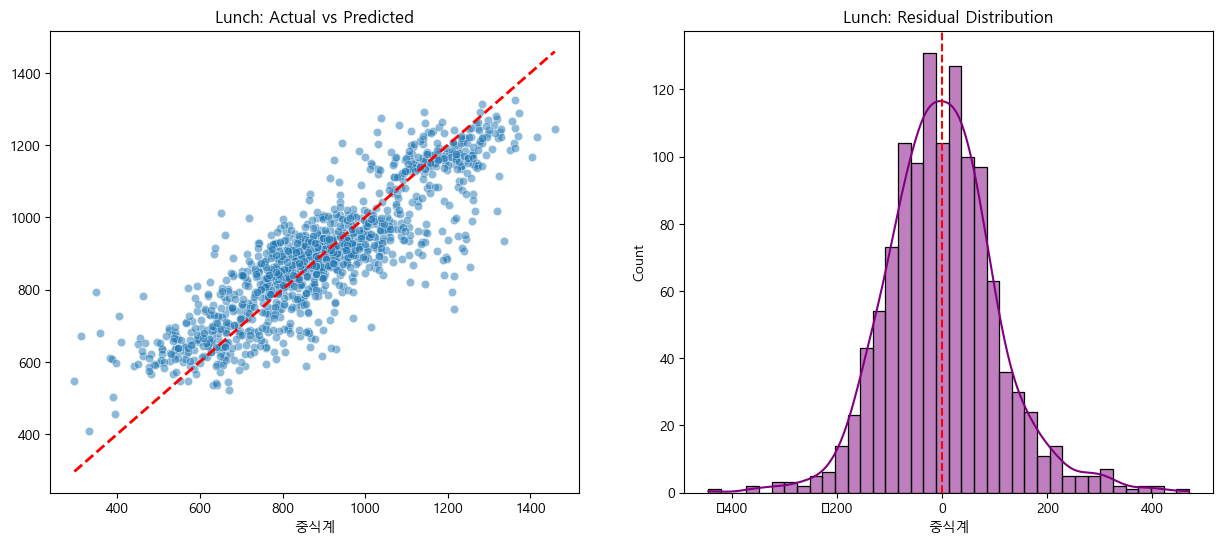

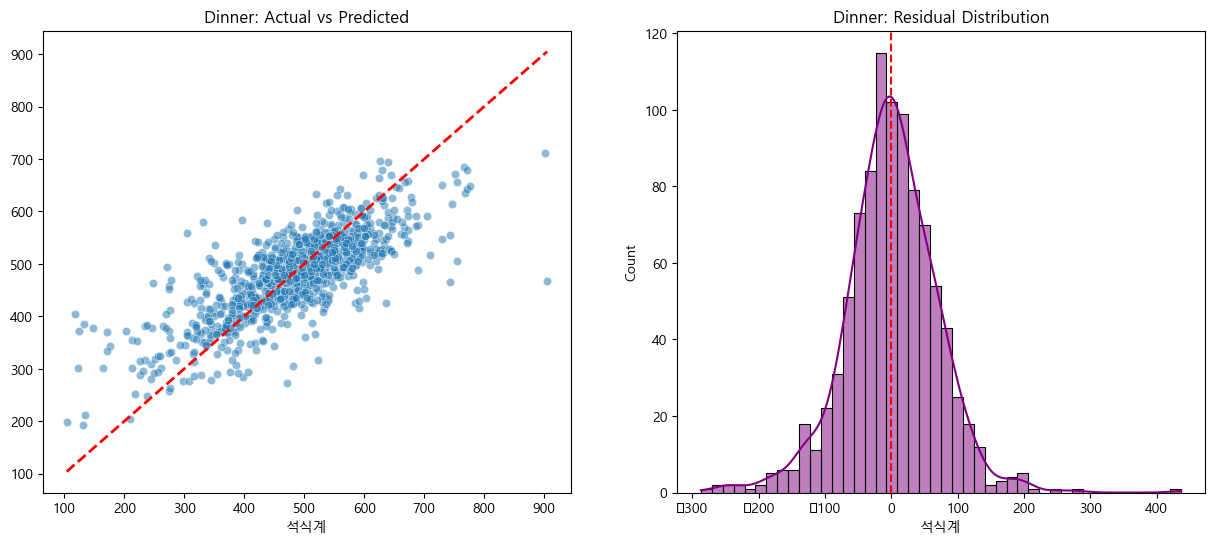

In [5]:
def plot_analysis(y_true, y_pred, title):
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.title(f'{title}: Actual vs Predicted')
    
    plt.subplot(1, 2, 2)
    residuals = y_true - y_pred
    sns.histplot(residuals, kde=True, color='purple')
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f'{title}: Residual Distribution')
    plt.show()

plot_analysis(res_l_y, res_l_oof, 'Lunch')
plot_analysis(res_d_y, res_d_oof, 'Dinner')

In [6]:
submission['중식계'] = res_l_pred
submission['석식계'] = res_d_pred
submission.to_csv('submission/dining_submission_v5_drop.csv', index=False)
print("Optimization Complete (Drop Strategy).")

Optimization Complete (Drop Strategy).
